# Enhanced POPANE Emotion Analysis

This notebook demonstrates comprehensive analysis using all POPANEpy utilities:
- **Data Loading**: Efficient querying from DuckDB
- **Signal Preprocessing**: Filtering, smoothing, and transformations
- **Frequency Analysis**: FFT, dominant frequency, signal energy
- **Visualization**: Multi-signal plots using POPANEFigureGenerator
- **Feature Engineering**: Aggregated statistical and frequency features
- **PCA & ML**: Dimensionality reduction and emotion classification

Modules utilized:
- `emotion.visualization.figure` - Signal plotting
- `emotion.preprocessing.analysis` - PCA, heatmaps
- `emotion.preprocessing.dataprocess` - Transformations, feature engineering
- `emotion.preprocessing.frequency` - Frequency filters and analysis

# POPANE Emotion Analysis

This notebook demonstrates data loading, EDA, PCA, and ML classification.

In [1]:
import dataclasses
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import duckdb
import importlib
#################################
from select import select
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import (StandardScaler,
                                   LabelEncoder)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import warnings
from sklearn.preprocessing import LabelEncoder

############################################

from emotion import POPANE
from emotion.models.random_forest import EmotionRandomForest
import emotion.preprocessing.analysis
importlib.reload(emotion.preprocessing.analysis)
from emotion.preprocessing.analysis import (generate_emotion_presence_matrix,
                                            generate_heatmap,
                                            generate_study_size_bar_chart)
from emotion.utils import get_size
from emotion.dataloader.popaneloader import POPANEDataLoader

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

output_dir = Path('../figures')
output_dir.mkdir(exist_ok=True)
print('Libraries imported!')

Libraries imported!


In [2]:
popane = POPANE("../data/raw/")
db_path = '../data/processed/popane_emotion.db'
conn = duckdb.connect(database=db_path, read_only=True)

# Limit memory and threads
conn.execute("SET memory_limit='512MB'")
conn.execute("SET threads=2")
tables = conn.execute('SHOW TABLES').fetchall()
print(f'Tables: {[t[0] for t in tables]}')

Tables: ['study1', 'study2', 'study3', 'study4', 'study5', 'study6', 'study7']


Unique emotions: 13


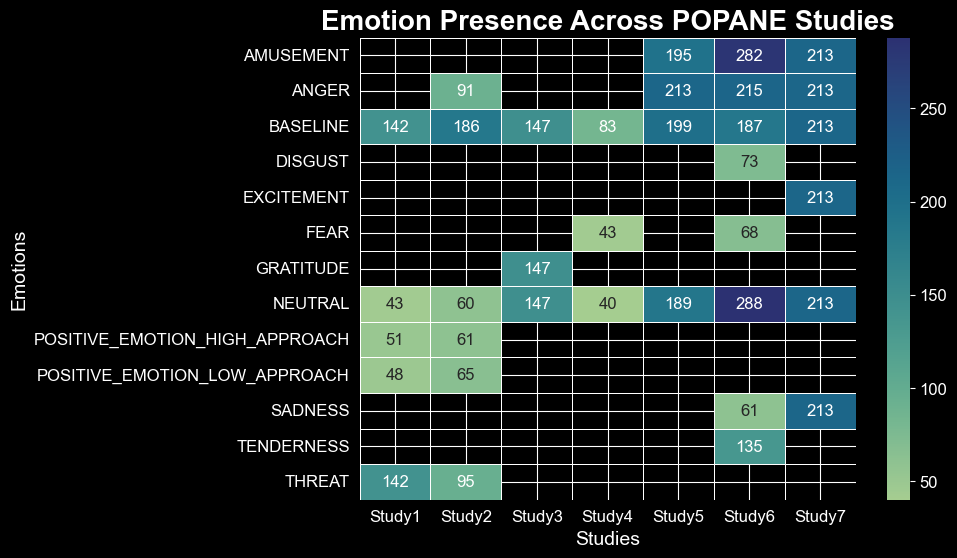

In [3]:
all_emotions = popane.get_unique_emotions_for_all_studies()
print(f'Unique emotions: {len(all_emotions)}')

loader = POPANEDataLoader("../data/raw/")
emotion_matrix = generate_emotion_presence_matrix(all_emotions, loader)

# plt.figure(figsize=(14, 8))
f = generate_heatmap(emotion_matrix)

In [4]:
# Get data from study5
query = '''
        SELECT * FROM study1
        WHERE SUBJECT_ID < 10
        '''
df_study1 = conn.execute(query).fetchdf()


In [5]:
df_study1

,Subject_ID,timestamp,affect,ECG,EDA,temp,respiration,SBP,DBP,marker
0,1,189.081,3.6,0.271,0.99,28.86,-0.60,80.28,65.84,-1
1,1,189.082,3.6,0.295,0.99,28.86,-0.61,82.69,67.09,-1
2,1,189.083,3.6,0.270,0.99,28.86,-0.61,84.06,66.88,-1
3,1,189.084,3.6,0.256,0.99,28.86,-0.61,85.31,66.94,-1
4,1,189.085,3.6,0.270,0.99,28.85,-0.61,87.47,67.31,-1
...,...,...,...,...,...,...,...,...,...,...
4589995,9,443.297,7.4,0.003,1.79,28.00,0.41,99.28,137.16,209
4589996,9,443.298,7.4,-0.008,1.79,28.00,0.41,101.16,137.78,209
4589997,9,443.299,7.4,-0.009,1.79,28.00,0.41,102.06,137.47,209
4589998,9,443.300,7.4,0.031,1.79,28.00,0.40,103.09,137.31,209


In [6]:
POPANEDataLoader("../data/raw").studies_meta_loader.get_subject_metadata(1, 1)

,SUBJECT_ID,SEX,AGE,HEIGHT,WEIGHT,STIMULI,STUDY_NAME,FILE_PATH,FILE_NAME,EMOTION
0,1,1,23.0,170.0,68.0,309,STUDY1,/Users/magana272/Desktop/popane/POPANEpy/data/...,1_BASELINE,BASELINE
1,1,1,23.0,170.0,68.0,309,STUDY1,/Users/magana272/Desktop/popane/POPANEpy/data/...,1_THREAT,THREAT
2,1,1,23.0,170.0,68.0,309,STUDY1,/Users/magana272/Desktop/popane/POPANEpy/data/...,1_POSITIVE_EMOTION_HIGH_APPROACH,POSITIVE_EMOTION_HIGH_APPROACH


## Signal Preprocessing & Visualization

Let's use the preprocessing utilities to visualize signal transformations and filtering.

Visualizing transformations: Original, Scaled, Smoothed, Scaled & Smoothed


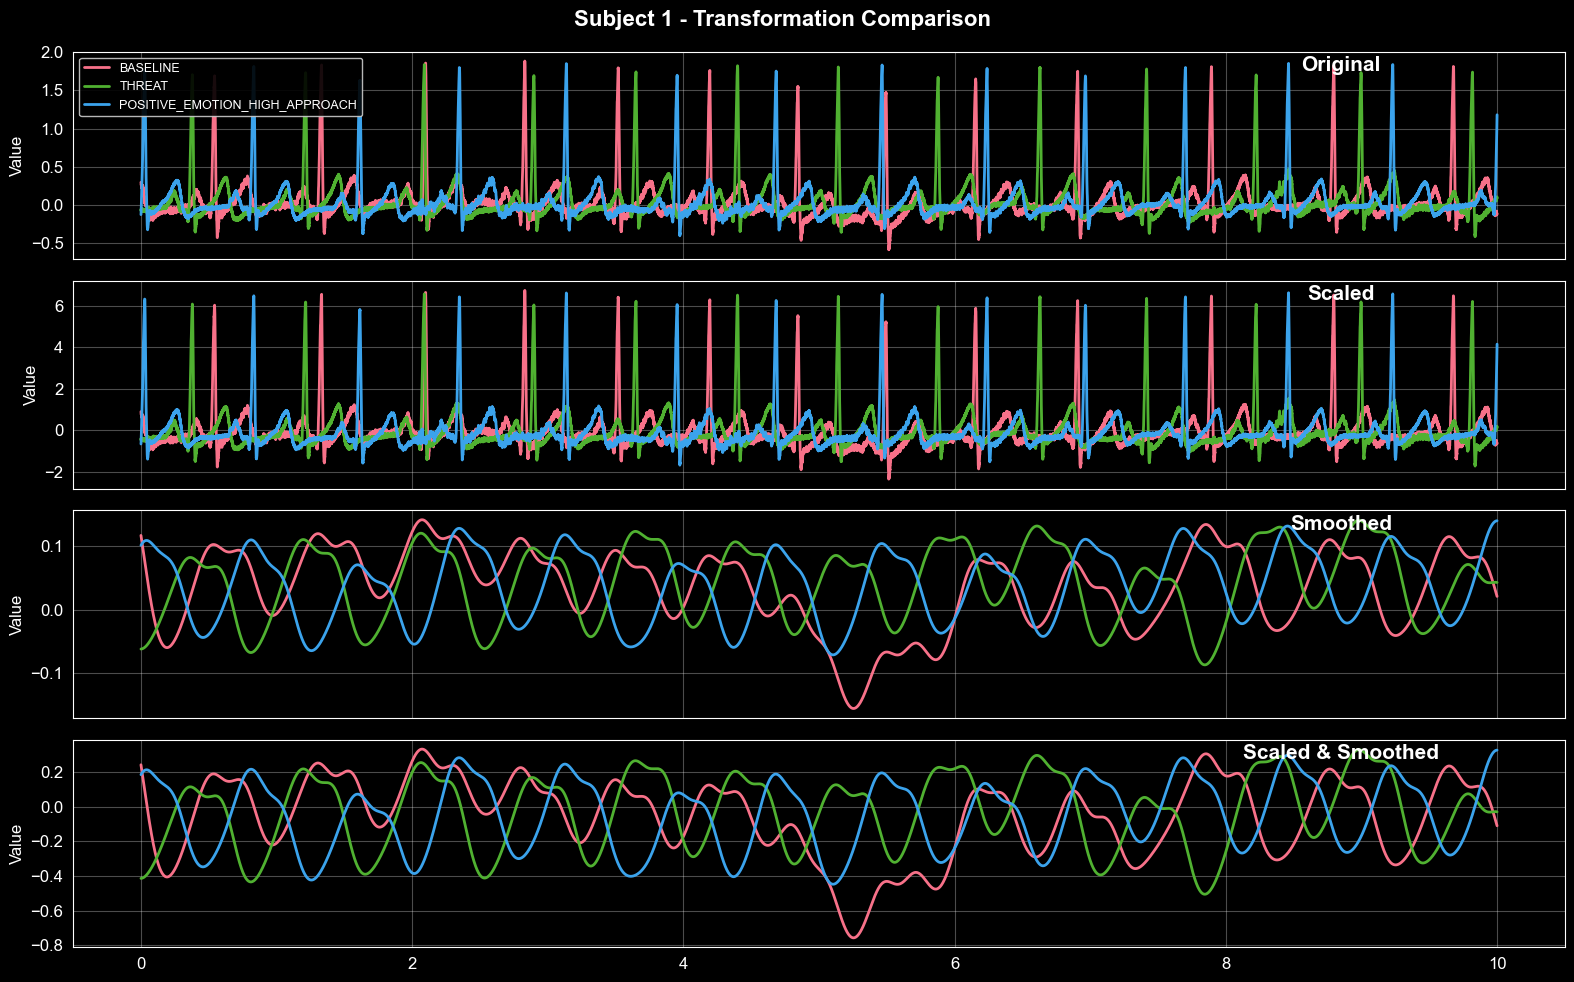

In [7]:
from emotion.preprocessing.dataprocess import (visualize_transformations,
                                              ECGSmoothTransformer,
                                              clean_DBP,
                                              create_aggregated_features)
from emotion.preprocessing.frequency import (mutlipass_filter,
                                             highpass_0_5hz,
                                             notch_filter,
                                             frequency_analysis,
                                             FrequencyDomainFeatureExtractor)

# Visualize different transformations on ECG signal
print("Visualizing transformations: Original, Scaled, Smoothed, Scaled & Smoothed")
visualize_transformations(study=1, subject_id=1,
                          data_path="../data/raw",
                          figsize=(16, 10),
                          start_end=(0, 10),
                          sigma=100) # Change the sigma

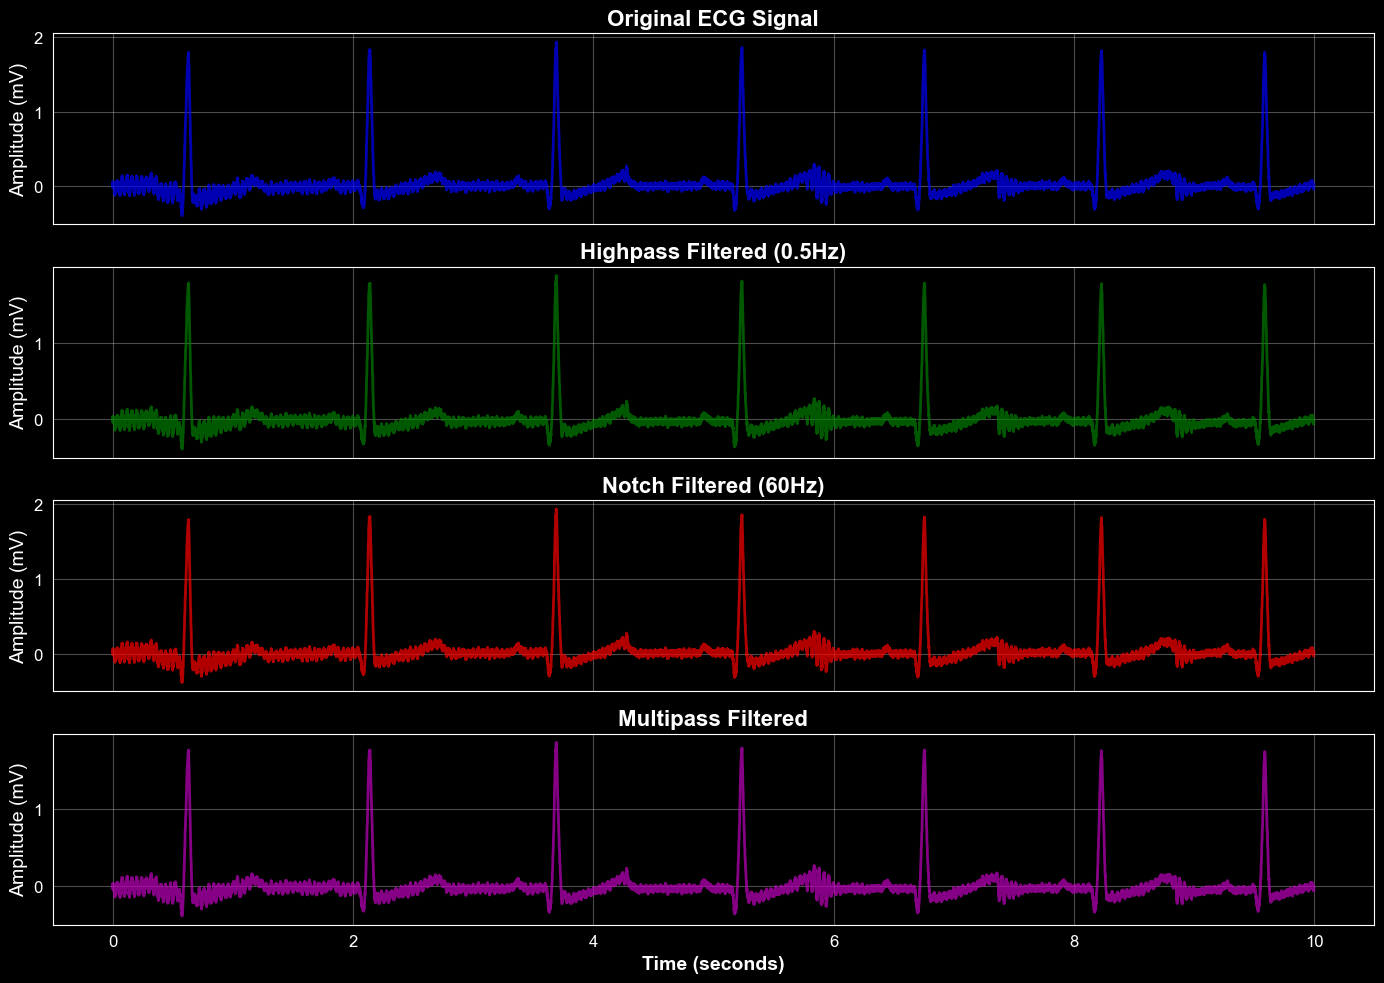

In [8]:
# Apply frequency domain filters
subject_1 = popane.get_subject(1, 2)
if subject_1:
    df_subject = subject_1.to_dataframe()

    # Get ECG signal
    ecg_signal = df_subject['ECG'].dropna().values[:5000]  # First 5000 samples

    # Apply different filters
    ecg_highpass = highpass_0_5hz(ecg_signal, fs=500)
    ecg_notch = notch_filter(ecg_signal, freq=60, fs=500)  # Remove 60Hz noise
    ecg_multipass = mutlipass_filter(ecg_signal, fs=500)

    # Visualize filtering effects
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    time = np.arange(len(ecg_signal)) / 500  # Convert to seconds

    axes[0].plot(time, ecg_signal, 'b-', alpha=0.7)
    axes[0].set_title('Original ECG Signal', fontweight='bold')
    axes[0].set_ylabel('Amplitude (mV)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(time, ecg_highpass, 'g-', alpha=0.7)
    axes[1].set_title('Highpass Filtered (0.5Hz)', fontweight='bold')
    axes[1].set_ylabel('Amplitude (mV)')
    axes[1].grid(alpha=0.3)

    axes[2].plot(time, ecg_notch, 'r-', alpha=0.7)
    axes[2].set_title('Notch Filtered (60Hz)', fontweight='bold')
    axes[2].set_ylabel('Amplitude (mV)')
    axes[2].grid(alpha=0.3)

    axes[3].plot(time, ecg_multipass, 'm-', alpha=0.7)
    axes[3].set_title('Multipass Filtered', fontweight='bold')
    axes[3].set_ylabel('Amplitude (mV)')
    axes[3].set_xlabel('Time (seconds)', fontweight='bold')
    axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_dir / 'frequency_filtering_comparison.png', dpi=300)
    plt.show()

## Frequency Domain Analysis

Analyze dominant frequencies and signal energy across emotions.

Analyzing frequency spectrum of DBP signal by emotion...
Dominant Frequency for 209: 1.3333333333648625 Hz
Signal Energy for 209: 28.61287618185464
Dominant Frequency for -1: 1.2633333333632073 Hz
Signal Energy for -1: 31.66838118177648
Dominant Frequency for 108: 1.2444444444738716 Hz
Signal Energy for 108: 31.048263109441802


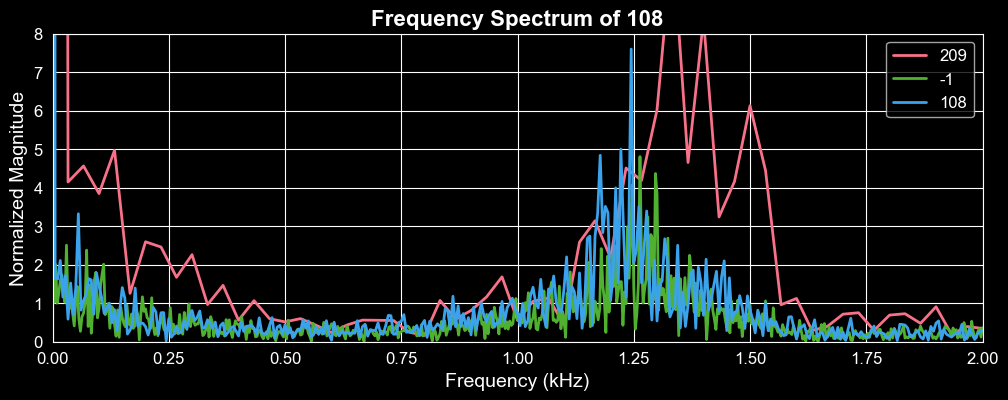

In [9]:
# Perform frequency analysis on DBP signal across emotions
if subject_1:
    df_freq = df_subject.copy()
    df_freq.rename(columns={'MARKER': 'EMOTION', 'TIMESTAMP': 'timestamp'}, inplace=True)
    print("Analyzing frequency spectrum of DBP signal by emotion...")
    frequency_analysis(df_freq)

In [10]:
# Extract frequency domain features
extractor = FrequencyDomainFeatureExtractor(sampling_rate=500)

# Extract features from ECG signal
if len(ecg_signal) > 0:
    freq_features = extractor.extract_features(ecg_signal)

    print("Frequency Domain Features:")
    for feature_name, value in freq_features.items():
        print(f"  {feature_name}: {value:.4f}")

Frequency Domain Features:
  dominant_frequency: 2.0000
  signal_energy: 341.6354


In [11]:
df_study1

,Subject_ID,timestamp,affect,ECG,EDA,temp,respiration,SBP,DBP,marker
0,1,189.081,3.6,0.271,0.99,28.86,-0.60,80.28,65.84,-1
1,1,189.082,3.6,0.295,0.99,28.86,-0.61,82.69,67.09,-1
2,1,189.083,3.6,0.270,0.99,28.86,-0.61,84.06,66.88,-1
3,1,189.084,3.6,0.256,0.99,28.86,-0.61,85.31,66.94,-1
4,1,189.085,3.6,0.270,0.99,28.85,-0.61,87.47,67.31,-1
...,...,...,...,...,...,...,...,...,...,...
4589995,9,443.297,7.4,0.003,1.79,28.00,0.41,99.28,137.16,209
4589996,9,443.298,7.4,-0.008,1.79,28.00,0.41,101.16,137.78,209
4589997,9,443.299,7.4,-0.009,1.79,28.00,0.41,102.06,137.47,209
4589998,9,443.300,7.4,0.031,1.79,28.00,0.40,103.09,137.31,209


In [12]:
from emotion.visualization.figure import POPANEFigureGenerator
query = '''
        SELECT Subject_ID, timestamp, affect, ECG, EDA, SBP,  DBP, temp , respiration, marker as STIMULI
        FROM study1
        WHERE Subject_ID < 10 and SUBJECT_ID
        '''
df_study1 = conn.execute(query).fetchdf()
df_study1 = df_study1.merge(POPANE().get_stimuli_meta(), how='inner', on=["STIMULI"])
df_study1.rename(columns={'Subject_ID': 'SUBJECT_ID', "STIMULI SHORTNAMEFILE":"EMOTION"}, inplace=True)
df_study1["STUDY_NAME"] = "STUDY1"
df_study1.rename({"Subject_ID": "study_id"}, inplace=True)

In [13]:
df_study1

,SUBJECT_ID,timestamp,affect,ECG,EDA,SBP,DBP,temp,respiration,STIMULI,STIMULI NAME,STIMULI TYPE,STIMULI VALENCE,EMOTION,USED IN STUDY,TIME INTERVAL IN SECONDS,STIMULI SOURCE - REFERENCES,STUDY_NAME
0,1,189.081,3.6,0.271,0.99,80.28,65.84,28.86,-0.60,-1,Physiobaseline,resting baseline,Neutral,Baseline,"1,2,3,4,5,6,7",300 (except of Study 3 = 180),NaN,STUDY1
1,1,189.082,3.6,0.295,0.99,82.69,67.09,28.86,-0.61,-1,Physiobaseline,resting baseline,Neutral,Baseline,"1,2,3,4,5,6,7",300 (except of Study 3 = 180),NaN,STUDY1
2,1,189.083,3.6,0.270,0.99,84.06,66.88,28.86,-0.61,-1,Physiobaseline,resting baseline,Neutral,Baseline,"1,2,3,4,5,6,7",300 (except of Study 3 = 180),NaN,STUDY1
3,1,189.084,3.6,0.256,0.99,85.31,66.94,28.86,-0.61,-1,Physiobaseline,resting baseline,Neutral,Baseline,"1,2,3,4,5,6,7",300 (except of Study 3 = 180),NaN,STUDY1
4,1,189.085,3.6,0.270,0.99,87.47,67.31,28.85,-0.61,-1,Physiobaseline,resting baseline,Neutral,Baseline,"1,2,3,4,5,6,7",300 (except of Study 3 = 180),NaN,STUDY1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4589995,9,443.297,7.4,0.003,1.79,99.28,137.16,28.00,0.41,209,Threat Speech,speech preapration,Negative,Threat,"1,2","study 1 = 30, study 2 = 180","24,25,38",STUDY1
4589996,9,443.298,7.4,-0.008,1.79,101.16,137.78,28.00,0.41,209,Threat Speech,speech preapration,Negative,Threat,"1,2","study 1 = 30, study 2 = 180","24,25,38",STUDY1
4589997,9,443.299,7.4,-0.009,1.79,102.06,137.47,28.00,0.41,209,Threat Speech,speech preapration,Negative,Threat,"1,2","study 1 = 30, study 2 = 180","24,25,38",STUDY1
4589998,9,443.300,7.4,0.031,1.79,103.09,137.31,28.00,0.40,209,Threat Speech,speech preapration,Negative,Threat,"1,2","study 1 = 30, study 2 = 180","24,25,38",STUDY1


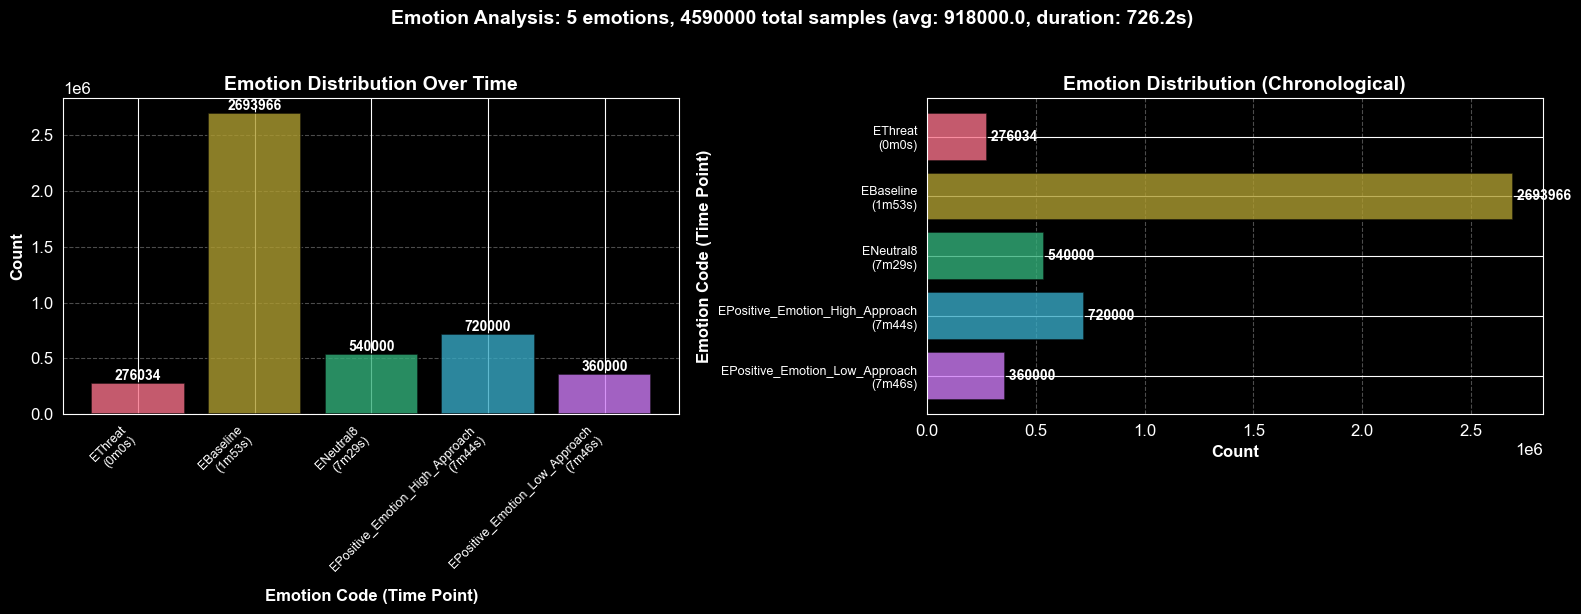

In [14]:
# Group by emotion and count samples, then add time point labels
emotion_counts = df_study1.groupby(['EMOTION', 'timestamp']).size().reset_index(name='count')
emotion_summary = df_study1.groupby('EMOTION').agg({
    'timestamp': ['min', 'max', 'count']
}).reset_index()
emotion_summary.columns = ['EMOTION', 'start_time', 'end_time', 'total_samples']
emotion_summary = emotion_summary.sort_values('start_time')

# Create time point labels (showing start time for each emotion)
time_labels = []
for idx, row in emotion_summary.iterrows():
    # Format time in a readable way (assuming timestamps are in seconds)
    start_sec = row['start_time']
    time_str = f"{int(start_sec//60)}m{int(start_sec%60)}s"
    time_labels.append(f"E{row['EMOTION']}\n({time_str})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot with time point labels
colors = sns.color_palette("husl", len(emotion_summary))
bars = axes[0].bar(range(len(emotion_summary)), emotion_summary['total_samples'].values,
                   color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Emotion Code (Time Point)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Emotion Distribution Over Time', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(emotion_summary)))
axes[0].set_xticklabels(time_labels, rotation=45, ha='right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, emotion_summary['total_samples'].values)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Horizontal bar plot with time information
axes[1].barh(range(len(emotion_summary)), emotion_summary['total_samples'].values,
            color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
axes[1].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Emotion Code (Time Point)', fontsize=12, fontweight='bold')
axes[1].set_title('Emotion Distribution (Chronological)', fontsize=14, fontweight='bold')
axes[1].set_yticks(range(len(emotion_summary)))
axes[1].set_yticklabels(time_labels, fontsize=9)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].invert_yaxis()

# Add value labels on horizontal bars
for i, count in enumerate(emotion_summary['total_samples'].values):
    axes[1].text(count, i, f' {int(count)}',
                va='center', ha='left', fontsize=10, fontweight='bold')

# Add statistics
total = emotion_summary['total_samples'].sum()
mean_count = emotion_summary['total_samples'].mean()
duration = emotion_summary['end_time'].max() - emotion_summary['start_time'].min()
fig.suptitle(f'Emotion Analysis: {len(emotion_summary)} emotions, {total} total samples (avg: {mean_count:.1f}, duration: {duration:.1f}s)',
            fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(output_dir / 'emotion_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Baseline Baseline
Baseline Positive_Emotion_High_Approach
Baseline Threat


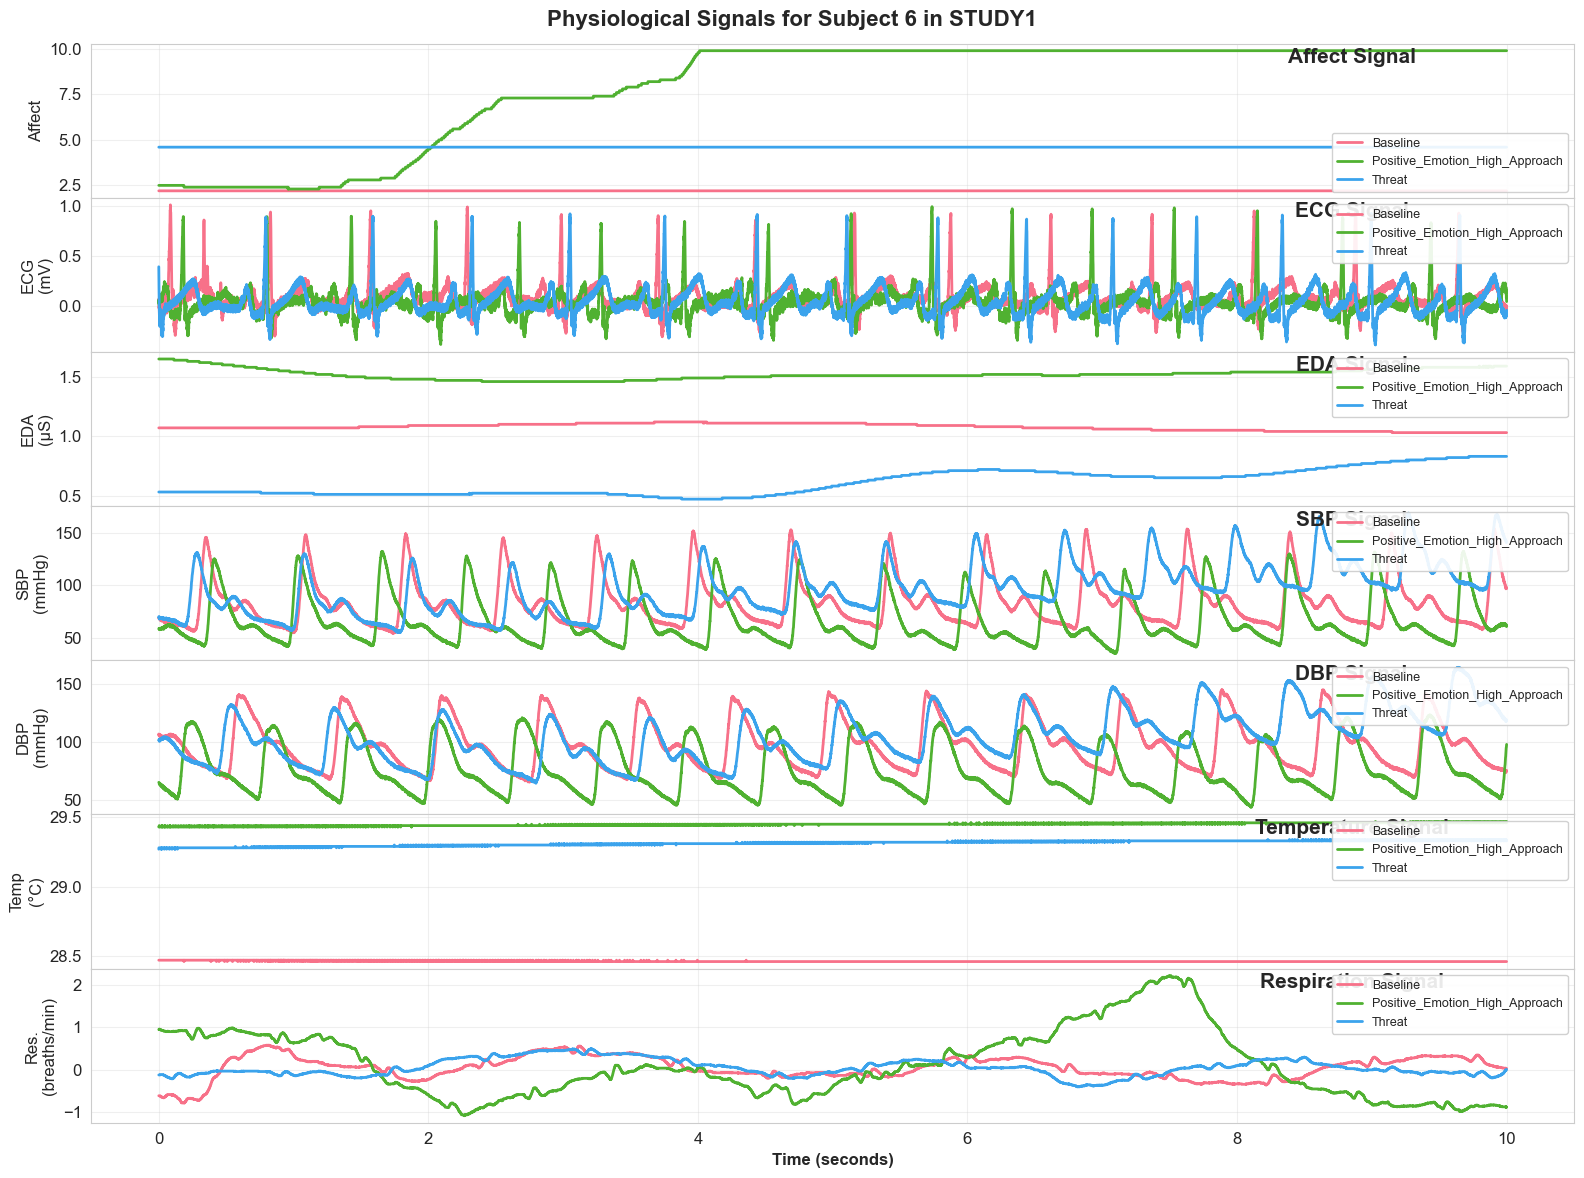

In [15]:
f= POPANEFigureGenerator.create_figure_for_subject(df_study1, 6, start_end=(0,10))

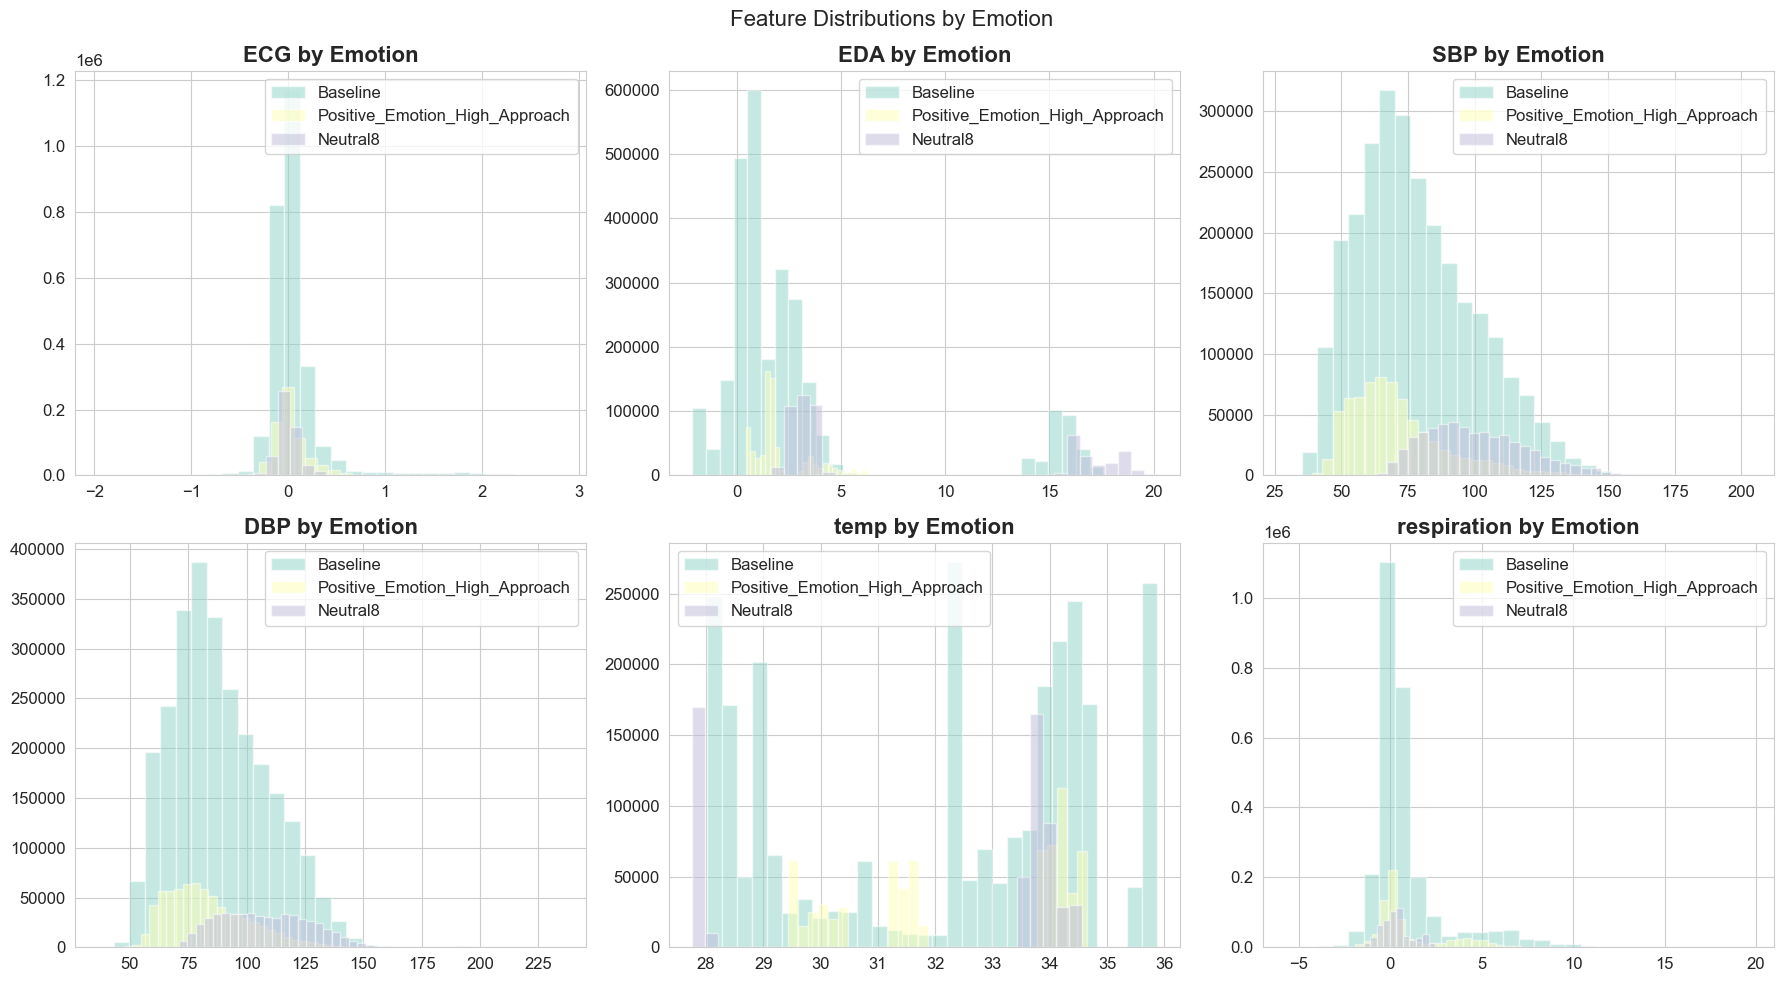

Saved: feature_distributions_by_emotion.png


In [15]:
top_emotions = df_study1['EMOTION'].value_counts().head(3).index.tolist()
df_sub = df_study1[df_study1['EMOTION'].isin(top_emotions)]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feat in enumerate(['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration']):
    ax = axes.flatten()[idx]
    if feat in df_sub.columns:
        for emo in top_emotions:
            data = df_sub[df_sub['EMOTION'] == emo][feat].dropna()
            ax.hist(data, alpha=0.5, bins=30, label=f'{emo}')
        ax.set_title(f'{feat} by Emotion')
        ax.legend()
plt.suptitle('Feature Distributions by Emotion', fontsize=16)
plt.tight_layout()
plt.savefig(output_dir / 'feature_distributions_by_emotion.png', dpi=300)
plt.show()
print('Saved: feature_distributions_by_emotion.png')

In [16]:
X = df_study1[['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration']].dropna()
y = df_study1.loc[X.index, 'EMOTION']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print(f'Features: {X.shape[1]}')
print(f'Explained variance (first 5): {pca.explained_variance_ratio_[:5]}')

Features: 6
Explained variance (first 5): [0.29402874 0.20811588 0.16742796 0.15372378 0.09921697]


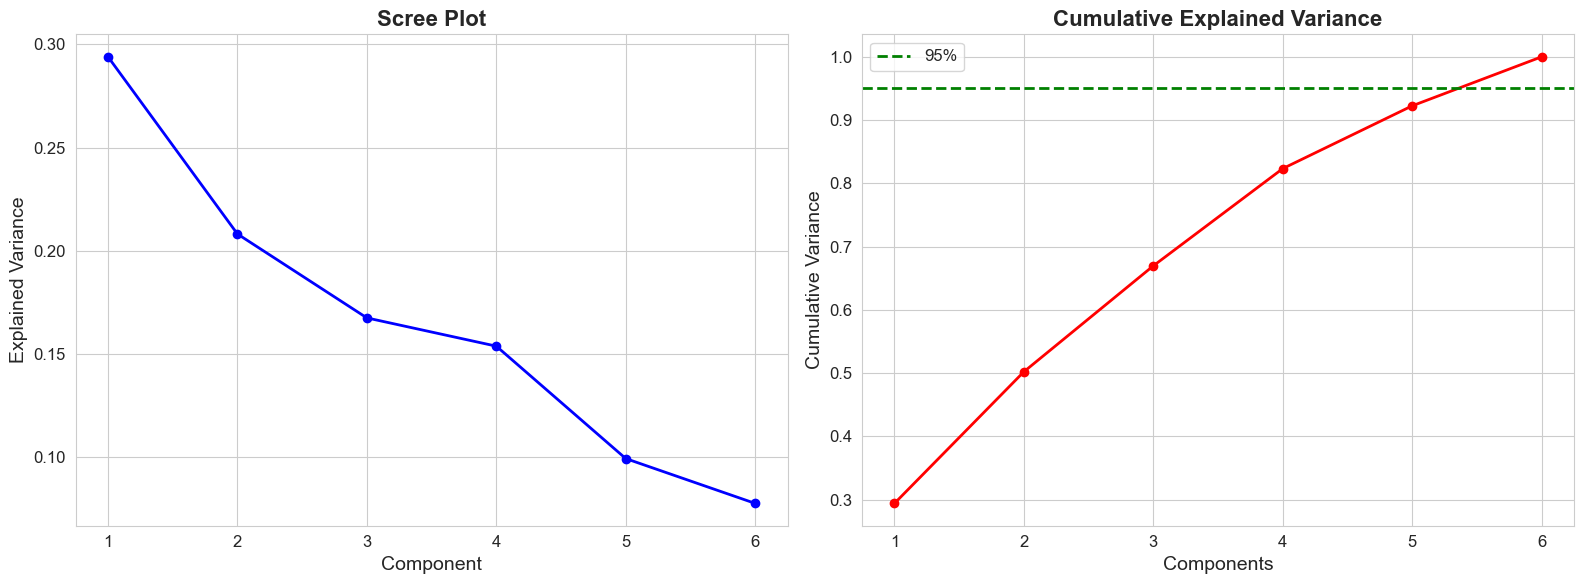

Components for 95% variance: 6
Saved: pca_explained_variance.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance')
axes[0].set_title('Scree Plot')
cumsum = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95%')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig(output_dir / 'pca_explained_variance.png', dpi=300)
plt.show()
n_comp_95 = np.argmax(cumsum >= 0.95) + 1
print(f'Components for 95% variance: {n_comp_95}')
print('Saved: pca_explained_variance.png')

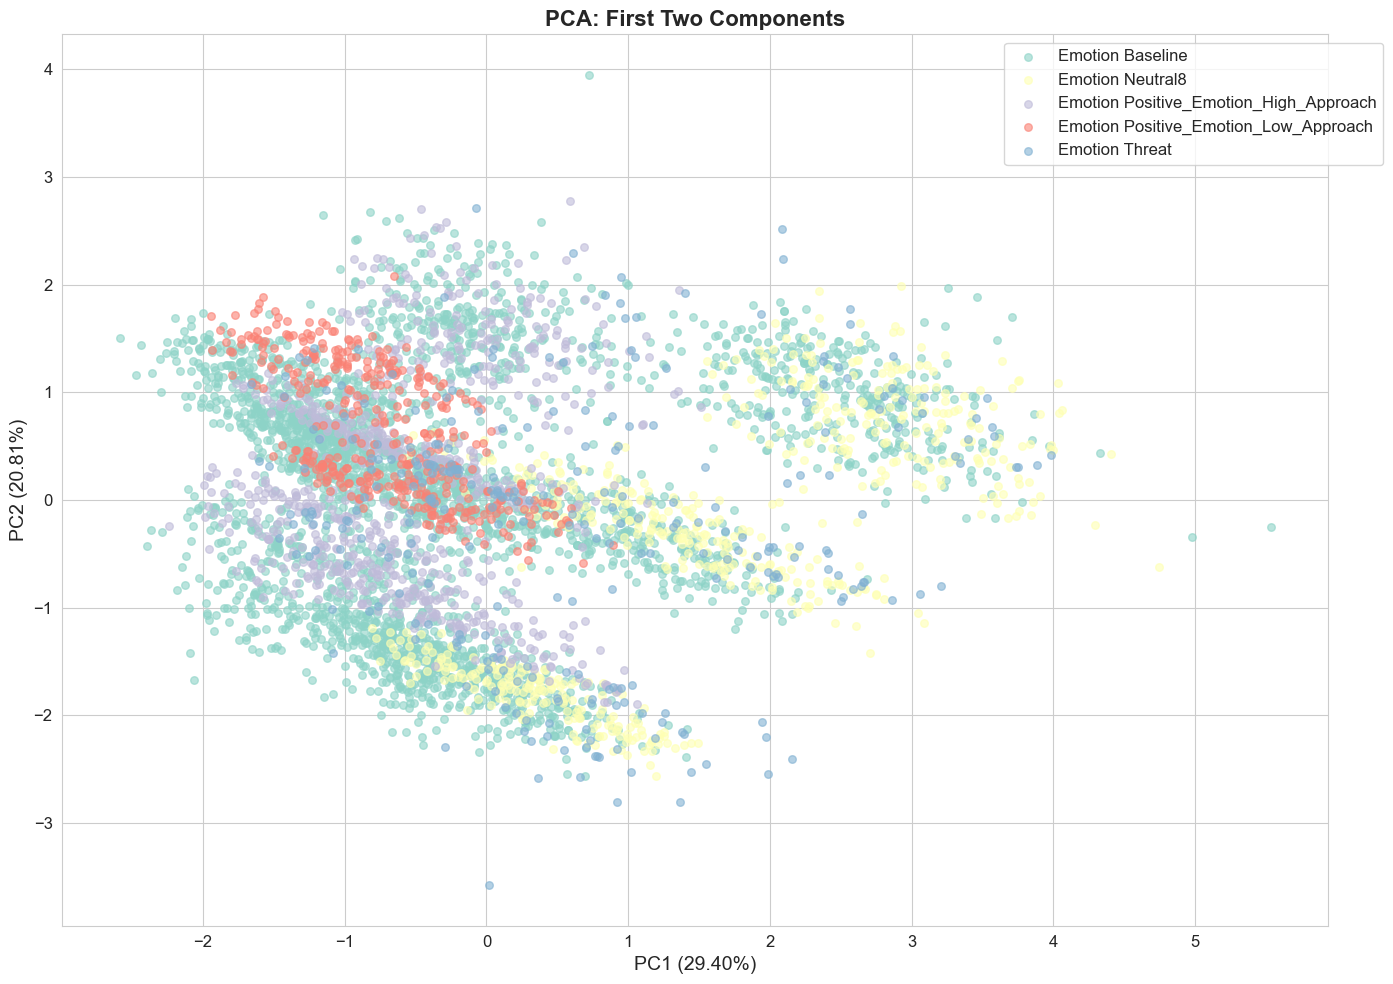

Saved: pca_2d_visualization.png


In [18]:
plt.figure(figsize=(14, 10))
sample_idx = np.random.choice(len(X_pca), min(5000, len(X_pca)), replace=False)
X_sample = X_pca[sample_idx]
y_sample = y.iloc[sample_idx]
for emo in y_sample.unique():
    mask = y_sample == emo
    plt.scatter(X_sample[mask, 0], X_sample[mask, 1], alpha=0.6, s=30, label=f'Emotion {emo}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA: First Two Components')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(output_dir / 'pca_2d_visualization.png', dpi=300)
plt.show()
print('Saved: pca_2d_visualization.png')

In [19]:
# Prepare full dataset for advanced feature engineering
print("Preparing dataset with advanced feature engineering...")
df_ml = df_study1.copy()
df_ml.rename(columns={
    'SUBJECT_ID': 'Subject_ID',
    'EMOTION': 'Emotion',
    'STUDY_NAME': 'Study_name',
    'timestamp': 'timestamp'
}, inplace=True)

# Ensure File_Name exists
if 'File_Name' not in df_ml.columns:
    df_ml["File_Name"] = df_ml["Subject_ID"].astype(str) + "_" + df_ml["Emotion"] + ".csv"

# Create aggregated features with statistical and frequency domain information
print("Creating aggregated features (statistical + frequency domain)...")
print("This may take a few moments for the full dataset...")

agg_features = create_aggregated_features(
    df_ml,
    resample_window='5s',  # 1 second windows
    batch_size=10
)

print(f"\nOriginal data shape: {df_ml.shape}")
print(f"Aggregated features shape: {agg_features.shape}")

# Prepare features and labels
# Select all numeric columns except timestamp and identifiers
exclude_cols = ['Subject_ID', 'Emotion', 'File_Name', 'Study_name', 'timestamp']
feature_cols = [col for col in agg_features.columns if col not in exclude_cols and agg_features[col].dtype in ['float64', 'int64']]

X_ml = agg_features[feature_cols].dropna()
y_ml = agg_features.loc[X_ml.index, 'Emotion']

# Encode labels
le = LabelEncoder()
y_ml_encoded = le.fit_transform(y_ml)

print(f'\nFinal dataset: {X_ml.shape}')
print(f'Number of features: {len(feature_cols)}')
print(f'Feature types: Statistical (mean, std, min, max, median) + Frequency (dominant_freq, signal_energy)')
print(f'Number of samples: {len(X_ml)}')
print(f'Number of classes: {len(le.classes_)}')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_ml_encoded
)

print(f'\nTrain set: {len(X_train)} samples')
print(f'Test set: {len(X_test)} samples')
print(f'\nTop 20 features:')
print(feature_cols[:20])

Preparing dataset with advanced feature engineering...
Creating aggregated features (statistical + frequency domain)...
This may take a few moments for the full dataset...
  Batch 1/3: Files 1-10
Creating aggregated features (statistical + frequency domain)...
This may take a few moments for the full dataset...
  Batch 1/3: Files 1-10
  Batch 2/3: Files 11-20
  Batch 2/3: Files 11-20
  Batch 3/3: Files 21-27
  Batch 3/3: Files 21-27

Original data shape: (4590000, 19)
Aggregated features shape: (943, 33)

Final dataset: (943, 28)
Number of features: 28
Feature types: Statistical (mean, std, min, max, median) + Frequency (dominant_freq, signal_energy)
Number of samples: 943
Number of classes: 5

Train set: 754 samples
Test set: 189 samples

Top 20 features:
['ECG_mean', 'ECG_median', 'ECG_std', 'ECG_min', 'ECG_max', 'ECG_dominant_freq', 'ECG_signal_energy', 'EDA_mean', 'EDA_median', 'EDA_std', 'EDA_min', 'EDA_max', 'EDA_dominant_freq', 'EDA_signal_energy', 'SBP_mean', 'SBP_median', 'SBP

## Advanced Feature Engineering

Create aggregated statistical and frequency-domain features for improved ML performance.

In [20]:
df_study1["File_Name"] = df_study1["SUBJECT_ID"].astype(str) + "_" + df_study1["EMOTION"] + ".csv"

In [21]:
# Create aggregated features with statistical and frequency domain information
print("Creating aggregated features (this may take a moment)...")
print("Features include: mean, median, std, min, max, dominant_freq, signal_energy")

# Prepare a small subset for demonstration
demo_df = df_study1.head(10000).copy()
demo_df.rename(columns={
    'SUBJECT_ID': 'Subject_ID',
    'EMOTION': 'Emotion',
    'FILE_NAME': 'File_Name',
    'STUDY_NAME': 'Study_name',
    'timestamp': 'timestamp'
}, inplace=True)

# Create aggregated features
agg_features = create_aggregated_features(
    demo_df,
    resample_window='1s',  # 1 second windows
    batch_size=5
)

print(f"\nOriginal data shape: {demo_df.shape}")
print(f"Aggregated features shape: {agg_features.shape}")
print(f"\nAggregated feature columns:")
print(agg_features.columns.tolist()[:20], "...")  # Show first 20 columns
print(f"\nSample of aggregated features:")
print(agg_features.head())

Creating aggregated features (this may take a moment)...
Features include: mean, median, std, min, max, dominant_freq, signal_energy
  Batch 1/1: Files 1-1

Original data shape: (10000, 19)
Aggregated features shape: (11, 33)

Aggregated feature columns:
['ECG_mean', 'ECG_median', 'ECG_std', 'ECG_min', 'ECG_max', 'ECG_dominant_freq', 'ECG_signal_energy', 'EDA_mean', 'EDA_median', 'EDA_std', 'EDA_min', 'EDA_max', 'EDA_dominant_freq', 'EDA_signal_energy', 'SBP_mean', 'SBP_median', 'SBP_std', 'SBP_min', 'SBP_max', 'SBP_dominant_freq'] ...

Sample of aggregated features:
   ECG_mean  ECG_median   ECG_std  ECG_min  ECG_max  ECG_dominant_freq  \
0  0.027514     -0.0450  0.249480   -0.431    1.691           7.616975   
1  0.056966      0.0040  0.240837   -0.378    1.834           8.000000   
2  0.100124      0.0270  0.320964   -0.322    1.885           8.000000   
3  0.045719     -0.0215  0.243883   -0.353    1.796           4.000000   
4  0.037649     -0.0310  0.300406   -0.467    1.762     

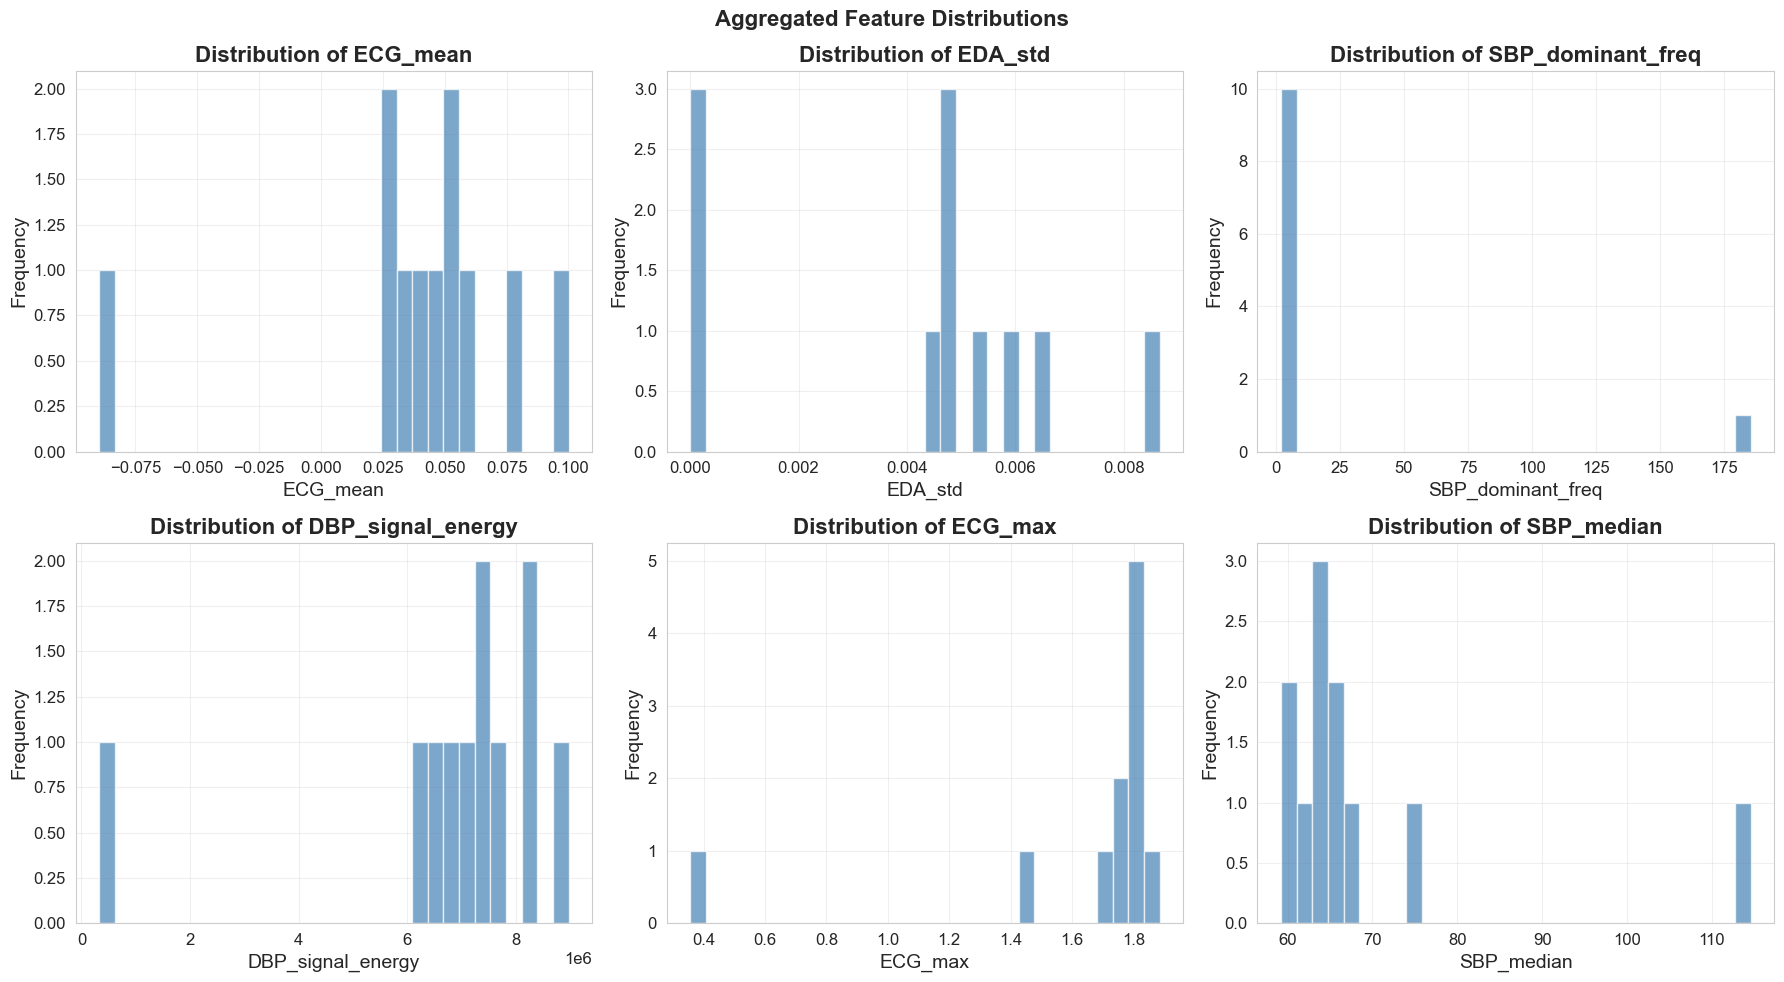

Saved: aggregated_feature_distributions.png


In [22]:
# Visualize aggregated feature importance
if not agg_features.empty:
    # Select numeric features only
    numeric_features = agg_features.select_dtypes(include=[np.number]).columns
    feature_stats = agg_features[numeric_features].describe()

    # Plot distribution of some key aggregated features
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    key_features = ['ECG_mean', 'EDA_std', 'SBP_dominant_freq',
                    'DBP_signal_energy', 'ECG_max', 'SBP_median']

    for idx, feat in enumerate(key_features):
        if feat in agg_features.columns:
            ax = axes.flatten()[idx]
            agg_features[feat].dropna().hist(bins=30, ax=ax, color='steelblue', alpha=0.7)
            ax.set_title(f'Distribution of {feat}', fontweight='bold')
            ax.set_xlabel(feat)
            ax.set_ylabel('Frequency')
            ax.grid(alpha=0.3)

    plt.suptitle('Aggregated Feature Distributions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'aggregated_feature_distributions.png', dpi=300)
    plt.show()
    print('Saved: aggregated_feature_distributions.png')

In [23]:
print('Training Random Forest with Advanced Engineered Features...')
print(f'Training on {len(feature_cols)} features (statistical + frequency domain)')

rf_model = RandomForestClassifier(
    n_estimators=100,  # Increased for better performance with more features
    max_depth=30,      # Deeper trees for complex feature interactions
    min_samples_leaf=20,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f'\n{"="*60}')
print(f'MODEL PERFORMANCE WITH ADVANCED FEATURES')
print(f'{"="*60}')
print(f'Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Overfitting: {(train_acc - test_acc)*100:.2f}%')
print(f'{"="*60}')

Training Random Forest with Advanced Engineered Features...
Training on 28 features (statistical + frequency domain)

MODEL PERFORMANCE WITH ADVANCED FEATURES
Train Accuracy: 0.8448 (84.48%)
Test Accuracy: 0.8201 (82.01%)
Overfitting: 2.47%


In [24]:
print('Classification Report:')
print(classification_report(y_test, y_pred_test))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       110
           1       0.74      0.77      0.76        22
           2       0.95      0.60      0.73        30
           3       1.00      0.87      0.93        15
           4       0.00      0.00      0.00        12

    accuracy                           0.82       189
   macro avg       0.70      0.64      0.66       189
weighted avg       0.78      0.82      0.79       189



In [25]:
cm = confusion_matrix(y_test, y_pred_test)

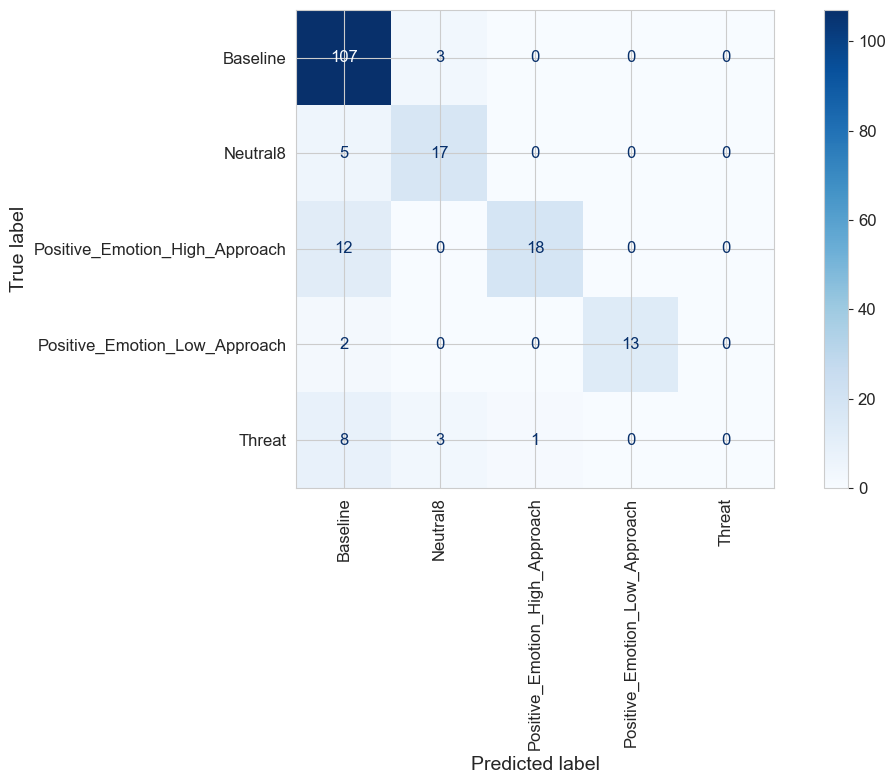

Saved: confusion_matrix.png


In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

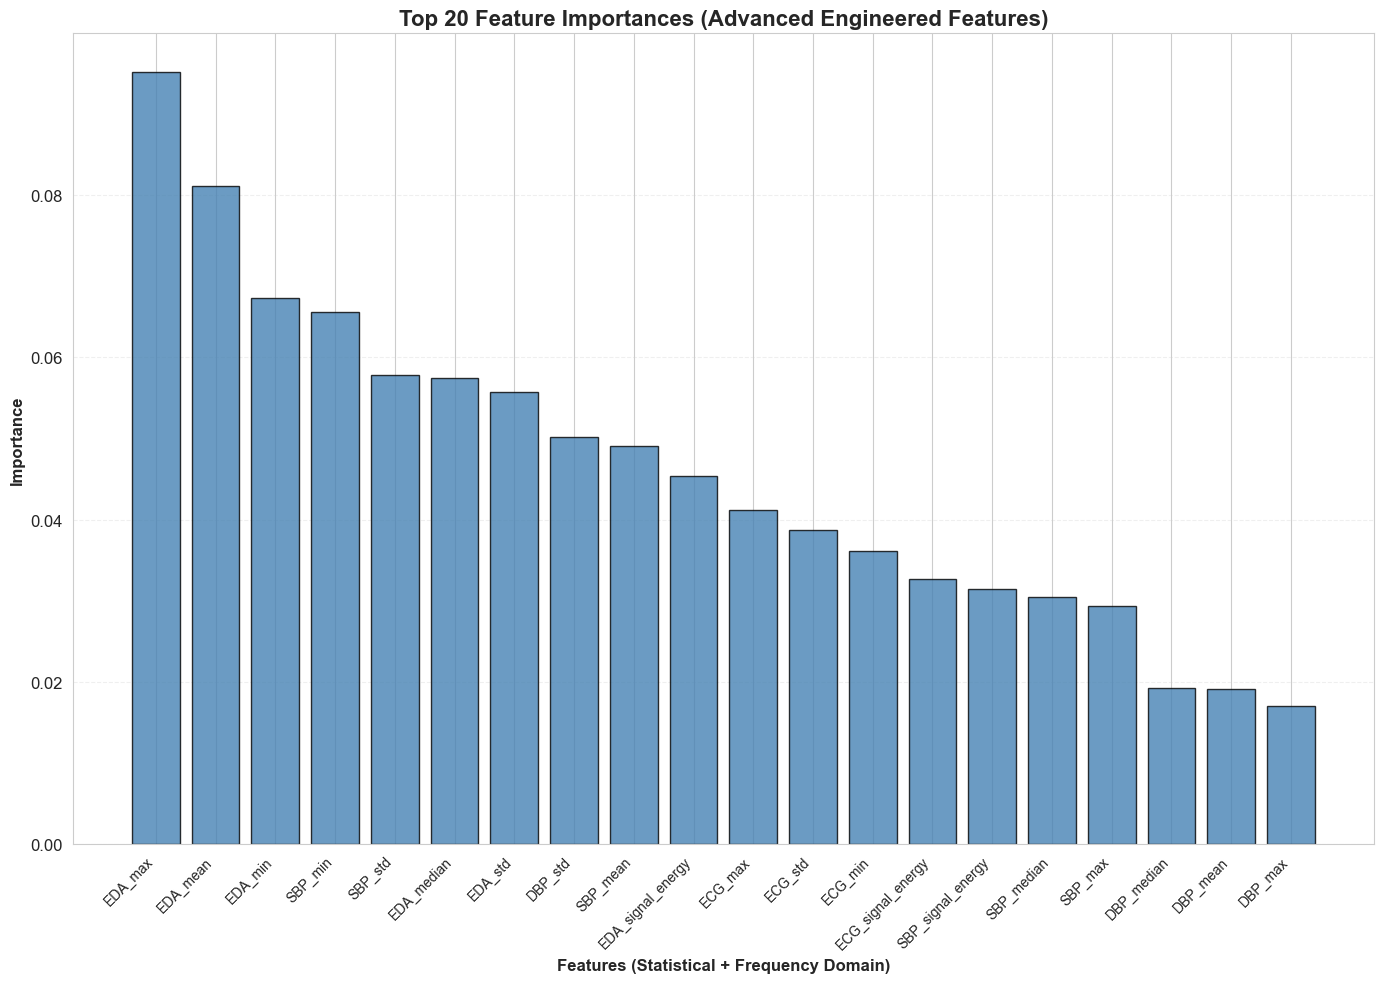

Saved: feature_importance.png

Top 20 Most Important Features:
 1. EDA_max                                  0.0952 (Statistical)
 2. EDA_mean                                 0.0811 (Statistical)
 3. EDA_min                                  0.0673 (Statistical)
 4. SBP_min                                  0.0656 (Statistical)
 5. SBP_std                                  0.0579 (Statistical)
 6. EDA_median                               0.0574 (Statistical)
 7. EDA_std                                  0.0558 (Statistical)
 8. DBP_std                                  0.0502 (Statistical)
 9. SBP_mean                                 0.0491 (Statistical)
10. EDA_signal_energy                        0.0454 (Frequency)
11. ECG_max                                  0.0411 (Statistical)
12. ECG_std                                  0.0387 (Statistical)
13. ECG_min                                  0.0361 (Statistical)
14. ECG_signal_energy                        0.0327 (Frequency)
15. SBP_signal_en

In [27]:
# Feature importance analysis for advanced features
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Show top 20 most important features
top_n = min(20, len(feature_cols))
top_indices = indices[:top_n]
top_features = [feature_cols[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(14, 10))
plt.bar(range(top_n), top_importances, color='steelblue', alpha=0.8, edgecolor='black')
plt.xticks(range(top_n), top_features, rotation=45, ha='right', fontsize=10)
plt.xlabel('Features (Statistical + Frequency Domain)', fontweight='bold', fontsize=12)
plt.ylabel('Importance', fontweight='bold', fontsize=12)
plt.title(f'Top {top_n} Feature Importances (Advanced Engineered Features)', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(output_dir / 'feature_importance.png', dpi=300)
plt.show()
print('Saved: feature_importance.png')

print(f'\nTop {top_n} Most Important Features:')
print(f'{"="*60}')
for rank, (feat, imp) in enumerate(zip(top_features, top_importances), 1):
    feat_type = "Frequency" if any(x in feat for x in ['dominant_freq', 'signal_energy']) else "Statistical"
    print(f'{rank:2d}. {feat:40s} {imp:.4f} ({feat_type})')
print(f'{"="*60}')

# Analyze feature type distribution
freq_features = [f for f in top_features if any(x in f for x in ['dominant_freq', 'signal_energy'])]
stat_features = [f for f in top_features if f not in freq_features]
print(f'\nFeature Type Distribution in Top {top_n}:')
print(f'  Statistical features: {len(stat_features)} ({len(stat_features)/top_n*100:.1f}%)')
print(f'  Frequency features: {len(freq_features)} ({len(freq_features)/top_n*100:.1f}%)')

In [28]:
conn.close()
print('='*50)
print('Analysis Complete!')
print('='*50)
print(f'\nTrain Accuracy: {train_acc:.2%}')
print(f'Test Accuracy: {test_acc:.2%}')
print(f'\nFigures saved:')
for f in sorted(output_dir.glob('*.png')):
    print(f'  - {f.name}')
print(f'\nComponents for 95%: {n_comp_95}')
# print(f'Top feature: {['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration'][indices[0]]}')

Analysis Complete!

Train Accuracy: 84.48%
Test Accuracy: 82.01%

Figures saved:
  - aggregated_feature_distributions.png
  - cm.png
  - emotion_distribution.png
  - emotions.png
  - feature_distributions_by_emotion.png
  - feature_importance.png
  - features.png
  - file_counts.png
  - frequency_filtering_comparison.png
  - pca_2d_visualization.png
  - pca_explained_variance.png

Components for 95%: 6


## Summary of Utility Functions Used


### Visualization (`emotion.visualization.figure`)
- `POPANEFigureGenerator.plot_signals()` - Plot physiological signals
- `POPANEFigureGenerator.create_figure_for_subject()` - Multi-panel subject plots

### Preprocessing (`emotion.preprocessing.dataprocess`)
- `visualize_transformations()` - Compare Original, Scaled, Smoothed signals
- `ECGSmoothTransformer` - Gaussian smoothing transformer
- `create_aggregated_features()` - Statistical + frequency features
- `clean_DBP()` - Rolling median filtering

### Frequency Analysis (`emotion.preprocessing.frequency`)
- `highpass_0_5hz()` - Remove low-frequency drift
- `notch_filter()` - Remove specific frequency noise (60Hz)
- `mutlipass_filter()` - Combined filtering pipeline
- `frequency_analysis()` - FFT analysis by emotion
- `FrequencyDomainFeatureExtractor` - Extract frequency features

### Analysis (`emotion.preprocessing.analysis`)
- `plot_pca()` - PCA visualization
- `generate_emotion_presence_matrix()` - Cross-study emotion heatmap
- `generate_heatmap()` - Visualization of emotion distribution
- `generate_study_size_bar_chart()` - Study size comparison
